# Training Log Tracker

Parse BiaPy partitioned SLURM train `.out` logs into a DataFrame and plot metrics across partitions (`biapy_work_folder/biapy_train_track.py`).

In [16]:
import os
import sys
from pathlib import Path

root = Path.cwd()
if root.name == "ipynb":
    root = root.parent
    os.chdir(root)
print(root)

if str(root) not in sys.path:
    sys.path.insert(0, str(root))

import matplotlib.pyplot as plt
import pandas as pd

from biapy_work_folder.biapy_train_track import (
    consolidate_training_log,
    plot_training_across_partitions,
)

/scratch/wmz2007/neuroinfo_fruitfly


## Load training log

Point `LOG_PATH` at a SLURM train `.out` under `sbatch/biapy/`.

In [17]:
# Archeived
    # Partition
    # "sbatch/biapy/BiaPy-py-biapy-channel-rot-seunet-train-15784784.out"
    # "sbatch/biapy/BiaPy-py-biapy-channel-rot-seunet-train-15784784.out"
    # "sbatch/biapy/BiaPy-py-biapy-channel-scale-unetr-train-15747672.out"
    # "sbatch/biapy/BiaPy-py-biapy-channel-scale-seunet-train-15747668.out"

    # Run 0 weight (1, 10, 10, 1) / zarr cos
    # "sbatch/biapy/biapy-instance-scale-zarr-seunet-train-15979567.out"
    # "sbatch/biapy/biapy-channel-scale-zarr-seunet-train-15975386.out"
    # "sbatch/biapy/biapy-channel-rot-zarr-unetr-train-15990905.out"

    # Run 0 weight (1, 5, 5, 1)
    # "sbatch/biapy/biapy-channel-scale-zarr-unetr-train-15990945.out"

    # Run 1 weight (1, 3, 3, 2) one cycle
    # "sbatch/biapy/biapy-channel-scale-zarr-unetr-train-16023896.out"

    # Channel-Scaling Run 0 
    # "sbatch/biapy/biapy-channel-scale-zarr-unetr-train-16044970.out"
    # "sbatch/biapy/biapy-channel-scale-zarr-seunet-train-16076092.out"

    # Instance-Scaling Run 0 
    # "sbatch/biapy/biapy-instance-scale-zarr-unetr-train-16051569.out"
    # "sbatch/biapy/biapy-instance-scale-zarr-seunet-train-16076096.out"

    # Channel-Scaling Run 1 
    # "sbatch/biapy/biapy-channel-scale-zarr-seunet-FP-train-16172365.out"
    # "sbatch/biapy/biapy-channel-scale-zarr-seunet-FDc-train-16172361.out"
    # "sbatch/biapy/biapy-channel-scale-zarr-seunet-train-16238457.out"

    # "sbatch/biapy/biapy-channel-scale-zarr-seunet-FDb-train-16217312.out"


In [18]:
LOG_PATH = Path(
    # Double Channel
    # # F C
    # "sbatch/biapy/biapy-channel-scale-zarr-seunet-FC-train-16238524.out"
    # # F D -- Failed
    # # "sbatch/biapy/biapy-channel-scale-zarr-seunet-FD-train-16238426.out"
    # # F Db
    # "sbatch/biapy/biapy-channel-scale-zarr-seunet-FDb-train-16217312.out" #r0
    # "sbatch/biapy/biapy-channel-scale-zarr-seunet-FDb-train-16451089.out" #r1
    # "sbatch/biapy/biapy-channel-scale-zarr-seunet-FDb-r2-train-16465352.out" #r2
    # # F Dc
    # "sbatch/biapy/biapy-channel-scale-zarr-seunet-FDc-train-16172361.out"
    # # F Dn 
    # "sbatch/biapy/biapy-channel-scale-zarr-seunet-FDn-train-16211106.out"
    # # F P
    # "sbatch/biapy/biapy-channel-scale-zarr-seunet-FP-train-16172365.out"

    # Multi Channel
    "sbatch/biapy/biapy-channel-scale-zarr-seunet-train-16410919.out"

)

df = consolidate_training_log(LOG_PATH)
print(
    f"{len(df)} epoch(s) across "
    f"{df['partition'].nunique() if not df.empty else 0} partition(s)"
)
df = df[df['global_step'] >= 5]
# df = df[df['partition'] != 0]
df.head()

35 epoch(s) across 1 partition(s)


,partition,epoch,global_step,train_loss,val_loss,train_iou_f,train_l1_dn,val_iou_f,val_l1_dn,lr,early_stopped,train_l1_dc_channel,train_iou_p_channel,val_l1_dc_channel,val_iou_p_channel
5,0,6,5,1.6534,1.3027,0.1271,0.0025,0.1811,0.0030,0.000280,True,0.0026,0.1417,0.0029,0.1472
6,0,7,6,0.9688,0.7571,0.2062,0.0022,0.2288,0.0021,0.000356,True,0.0025,0.1948,0.0023,0.1906
7,0,8,7,0.5705,0.4803,0.2392,0.0021,0.1439,0.0023,0.000437,True,0.0025,0.2221,0.0026,0.1361
8,0,9,8,0.3579,0.3727,0.2666,0.0018,0.2720,0.0016,0.000520,True,0.0022,0.2460,0.0016,0.2136
9,0,10,9,0.2541,0.2722,0.2837,0.0018,0.1678,0.0018,0.000603,True,0.0020,0.2598,0.0017,0.1551


## Plot across partitions

X-axis is `global_step` (epochs concatenated across partitions). Dashed vertical lines mark partition boundaries.

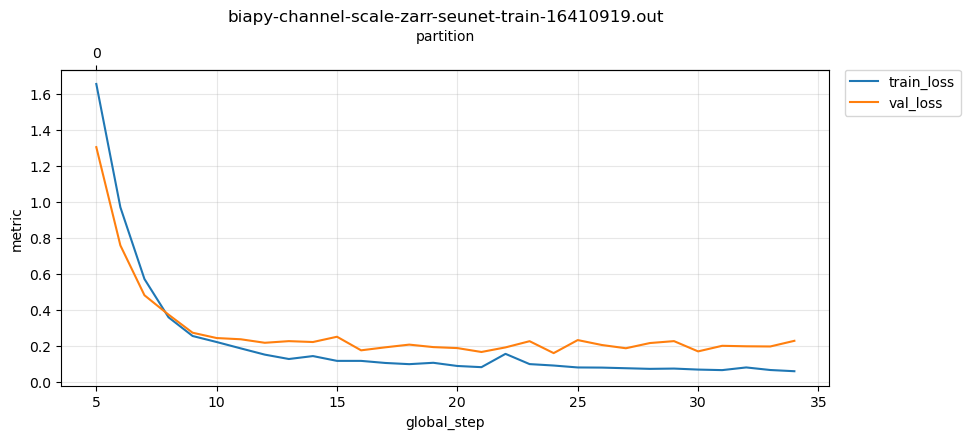

In [19]:
fig = plot_training_across_partitions(
    df,
    metrics=("train_loss", "val_loss"),
    # Avail metrics: train_iou_f,train_iou_c,train_l1_db,train_l1_dn,val_iou_f,val_iou_c,val_l1_db,val_l1_dn,lr,early_stopped
    title=LOG_PATH.name,
)
plt.show()

## Optional: other metrics

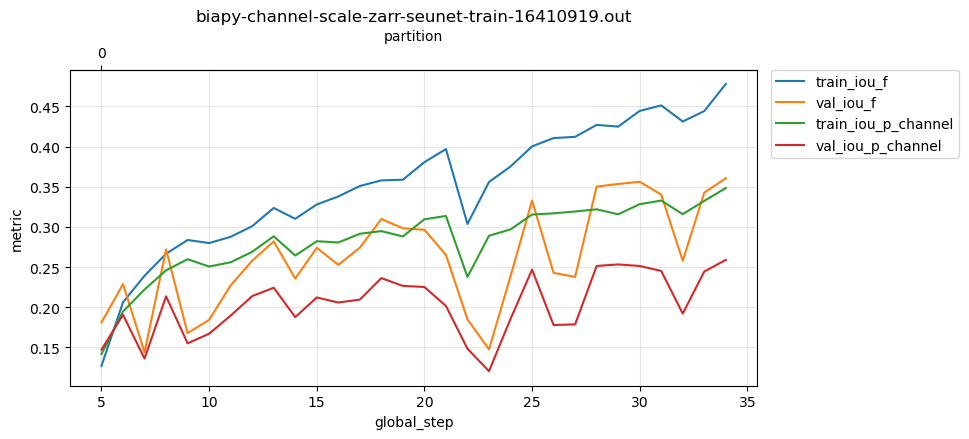

In [20]:
fig = plot_training_across_partitions(
    df,
    metrics=(
        "train_iou_f", "val_iou_f", 
        "train_iou_p_channel", "val_iou_p_channel",
        # "train_iou_c", "val_iou_c"
        # "train_l1_dn", "val_l1_dn",
        # "train_l1_db", "val_l1_db"
        # "train_l1_dc_channel", "val_l1_dc_channel"
    ),
    title=f"{LOG_PATH.name}",
)
plt.show()

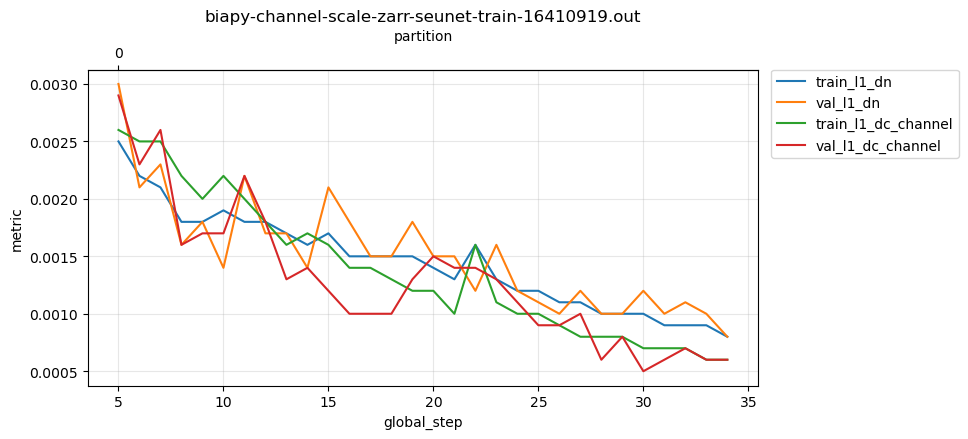

In [21]:
fig = plot_training_across_partitions(
    df,
    metrics=(
        # "train_iou_f", "val_iou_f", 
        # "train_iou_c", "val_iou_c"
        # "train_iou_p_channel", "val_iou_p_channel"
        # "train_l1_db", "val_l1_db"
        "train_l1_dn", "val_l1_dn",
        "train_l1_dc_channel", "val_l1_dc_channel"
    ),
    title=f"{LOG_PATH.name}",
)
plt.show()